# Paclitaxel Multi-omics Figures

This notebook generates manuscript-ready figure panels for the paclitaxel multi-omics classification case study. It reads the saved outputs from `2-ML.ipynb` and does not rerun model training.

## Imports and Paths

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, mannwhitneyu, pointbiserialr
from sklearn.metrics import (
    auc,
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore")

from pipeline_utils import make_case4_paths

paths = make_case4_paths()
DATA_DIR = paths["proc"]
RESULTS_DIR = paths["results"]
FIGURE_DIR = paths["figures"]

sys.path.append(str(paths["project"] / "4_paclitaxel"))
from feature_sets import add_binary_response

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

RESPONSE_ORDER = ["Resistant", "Sensitive"]
MRECIST_ORDER = ["PD", "SD", "PR", "CR"]
PALETTE_BINARY = {"Resistant": "#4C78A8", "Sensitive": "#E45756"}
PALETTE_MRECIST = {"PD": "#4C78A8", "SD": "#72B7B2", "PR": "#F58518", "CR": "#E45756"}

print("Project root:", paths["project"])
print("Figure dir:", FIGURE_DIR)

Project root: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study
Figure dir: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures


## Load Data and Results

In [2]:
metadata_df = add_binary_response(pd.read_csv(DATA_DIR / "metadata.csv", index_col=0))

single_results_df = pd.read_csv(RESULTS_DIR / "single_omics_classification_cv_results.csv")
single_predictions_df = pd.read_csv(RESULTS_DIR / "single_omics_classification_cv_predictions.csv")
early_results_df = pd.read_csv(RESULTS_DIR / "early_fusion_classification_cv_results.csv")
early_predictions_df = pd.read_csv(RESULTS_DIR / "early_fusion_classification_cv_predictions.csv")
late_results_df = pd.read_csv(RESULTS_DIR / "late_fusion_classification_cv_results.csv")
late_predictions_df = pd.read_csv(RESULTS_DIR / "late_fusion_classification_cv_predictions.csv")
summary_df = pd.read_csv(RESULTS_DIR / "classification_model_summary.csv")
response_qc_df = pd.read_csv(RESULTS_DIR / "response_metric_qc.csv")

all_results_df = pd.concat([single_results_df, early_results_df, late_results_df], ignore_index=True)
all_predictions_df = pd.concat([single_predictions_df, early_predictions_df, late_predictions_df], ignore_index=True)

print("metadata", metadata_df.shape)
print("all_results", all_results_df.shape)
print("all_predictions", all_predictions_df.shape)
summary_df.head(10)

metadata (80, 5)
all_results (525, 31)
all_predictions (6610, 14)


,analysis,omics,model,auroc_mean,auroc_sd,auprc_mean,auprc_sd,balanced_accuracy_mean,balanced_accuracy_sd,f1_mean,sensitivity_mean,specificity_mean,n_features_mean
0,early_fusion,rna_cnv_mutation,random_forest,0.658286,0.134078,0.667263,0.111549,0.612762,0.121062,0.554571,0.536000,0.689524,2948.76
1,single_omics,rna_all,random_forest,0.651973,0.134209,0.673706,0.117467,0.619524,0.127177,0.596428,0.593333,0.645714,2054.88
2,single_omics,rna_paired,logistic_l2,0.643111,0.124479,0.688446,0.115672,0.613238,0.094138,0.610761,0.662667,0.563810,2055.68
3,single_omics,rna_paired,random_forest,0.638381,0.128443,0.661204,0.109191,0.604286,0.101621,0.538304,0.513333,0.695238,2055.68
4,single_omics,rna_all,logistic_l2,0.637007,0.143374,0.691064,0.120166,0.574762,0.122399,0.558446,0.578095,0.571429,2054.88
5,early_fusion,rna_cnv_mutation,logistic_l2,0.635841,0.111700,0.667551,0.112208,0.590286,0.086206,0.602346,0.685333,0.495238,2948.76
6,late_fusion_stacking,rna_cnv_mutation,stack_logistic_l2,0.544349,0.160374,0.605884,0.141528,0.538476,0.117812,0.519194,0.549333,0.527619,3.00
7,single_omics,cnv,random_forest,0.533714,0.150305,0.589740,0.133133,0.527048,0.124513,0.513732,0.556000,0.498095,401.16
8,single_omics,rna_paired,logistic_l1,0.510190,0.145314,0.567165,0.130594,0.500190,0.144038,0.391472,0.408000,0.592381,2055.68
9,single_omics,rna_paired,svm_rbf,0.504698,0.132211,0.582072,0.113874,0.570952,0.099232,0.492843,0.533333,0.608571,2055.68


## Helper Functions

In [3]:
def savefig(name):
    png_path = FIGURE_DIR / f"{name}.png"
    pdf_path = FIGURE_DIR / f"{name}.pdf"
    plt.savefig(png_path, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    print("saved", png_path)
    print("saved", pdf_path)


def model_label(row):
    analysis = row["analysis"]
    omics = row["omics"]
    model = row["model"]
    if analysis == "single_omics":
        label_map = {
            "rna_paired": "RNA only",
            "rna_all": "RNA only (all)",
            "cnv": "CNV only",
            "mutation": "Mutation only",
        }
        return f"{label_map.get(omics, omics)}\n{model}"
    if analysis == "early_fusion":
        return f"Early fusion\n{model}"
    if analysis == "late_fusion_stacking":
        return f"Late fusion\n{model}"
    return f"{analysis}\n{model}"


def metric_summary(results_df, metric="auroc"):
    return (
        results_df
        .groupby(["analysis", "omics", "model"])
        .agg(
            metric_mean=(metric, "mean"),
            metric_sd=(metric, "std"),
            n_folds=(metric, "count"),
        )
        .reset_index()
    )


def pooled_curve_data(pred_df, model, analysis=None, omics=None):
    sub = pred_df[pred_df["model"] == model].copy()
    if analysis is not None:
        sub = sub[sub["analysis"] == analysis]
    if omics is not None:
        sub = sub[sub["omics"] == omics]
    if sub.empty:
        raise ValueError("No predictions found for requested model/analysis/omics.")
    return sub


## Figure 1: Response Definition and Metric Alignment

saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/response_endpoint_qc.png
saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/response_endpoint_qc.pdf


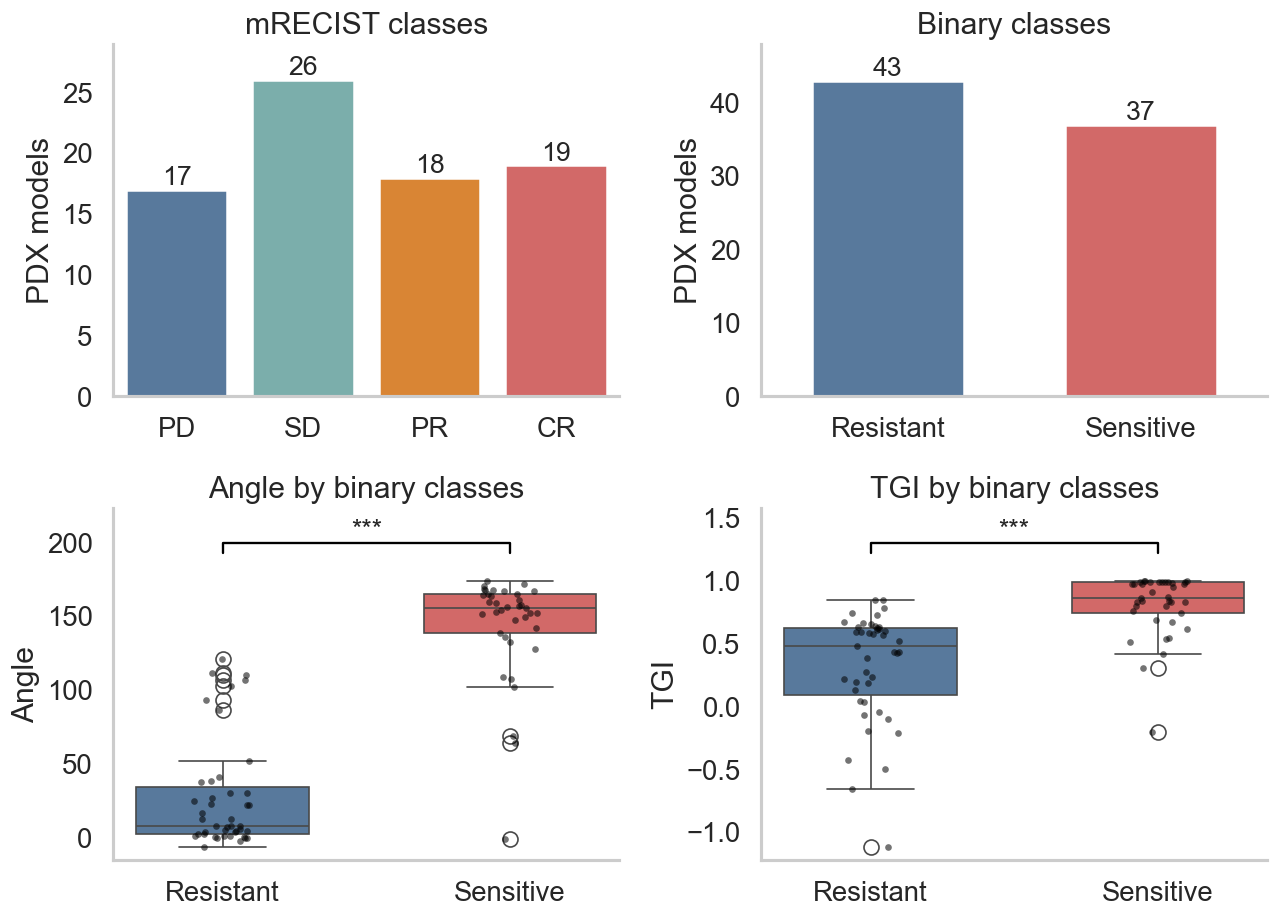

,metric,resistant_median,sensitive_median,mann_whitney_p,point_biserial_r,point_biserial_p,auroc,auprc
0,angle,7.893697,155.669929,1.998069e-12,0.847979,3.306680e-23,0.958517,0.968855
1,TGI,0.479326,0.865891,6.280624e-09,0.556356,8.401679e-08,0.878693,0.896106


In [4]:
from statannotations.Annotator import Annotator

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

sns.countplot(
    data=metadata_df,
    x="mRECIST",
    order=MRECIST_ORDER,
    palette=PALETTE_MRECIST,
    ax=axes[0, 0],
)
# write number as integer on top of each bar
for p in axes[0, 0].patches:
    height = p.get_height()
    axes[0, 0].annotate(f"{int(height)}", (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=16)
axes[0, 0].set_title("mRECIST classes")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("PDX models")
# set y lim to be max+3
axes[0, 0].set_ylim(0, metadata_df["mRECIST"].value_counts().max() + 3)

sns.countplot(
    data=metadata_df,
    x="response_binary",
    order=RESPONSE_ORDER,
    palette=PALETTE_BINARY,
    ax=axes[0, 1],
    width=0.6
)
for p in axes[0, 1].patches:
    height = p.get_height()
    axes[0, 1].annotate(f"{int(height)}", (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=16)
axes[0, 1].set_title("Binary classes")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("PDX models")
axes[0, 1].set_ylim(0, metadata_df["response_binary"].value_counts().max() + 5)


sns.boxplot(
    data=metadata_df,
    x="response_binary",
    y="angle",
    order=RESPONSE_ORDER,
    palette=PALETTE_BINARY,
    ax=axes[1, 0],
    width=0.6
)

sns.stripplot(
    data=metadata_df,
    x="response_binary",
    y="angle",
    order=RESPONSE_ORDER,
    color="black",
    alpha=0.55,
    size=4,
    ax=axes[1, 0],
)
axes[1, 0].set_title("Angle by binary classes")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Angle")

sns.boxplot(
    data=metadata_df,
    x="response_binary",
    y="TGI",
    order=RESPONSE_ORDER,
    palette=PALETTE_BINARY,
    ax=axes[1, 1],
    width=0.6
)
sns.stripplot(
    data=metadata_df,
    x="response_binary",
    y="TGI",
    order=RESPONSE_ORDER,
    color="black",
    alpha=0.55,
    size=4,
    ax=axes[1, 1],
)
axes[1, 1].set_title("TGI by binary classes")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("TGI")
# add statistical significance annotation for the boxplots based on "response_qc_df"
def p_to_stars(p):
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def add_response_pvalue(ax, metric):
    pval = response_qc_df.loc[
        response_qc_df["metric"].eq(metric), "mann_whitney_p"
    ].iloc[0]
    ymin, ymax = ax.get_ylim()
    yrange = ymax - ymin
    y = ymax + 0.05 * yrange
    h = 0.035 * yrange
    ax.plot([0, 0, 1, 1], [y, y + h, y + h, y], c="black", lw=1.4, clip_on=False)
    ax.text(0.5, y + h, p_to_stars(pval), ha="center", va="bottom", fontsize=16)
    ax.set_ylim(ymin, y + h + 0.12 * yrange)


add_response_pvalue(axes[1, 0], "angle")
add_response_pvalue(axes[1, 1], "TGI")

# remove grid lines for the boxplots
axes[0, 0].grid(False)
axes[0, 1].grid(False)
axes[1, 0].grid(False)
axes[1, 1].grid(False)
# remove top and right border lines for all subplots
for ax in axes.flatten():
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
savefig("response_endpoint_qc")
plt.show()

response_qc_df

saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/angle_vs_tgi_scatter.png
saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/angle_vs_tgi_scatter.pdf


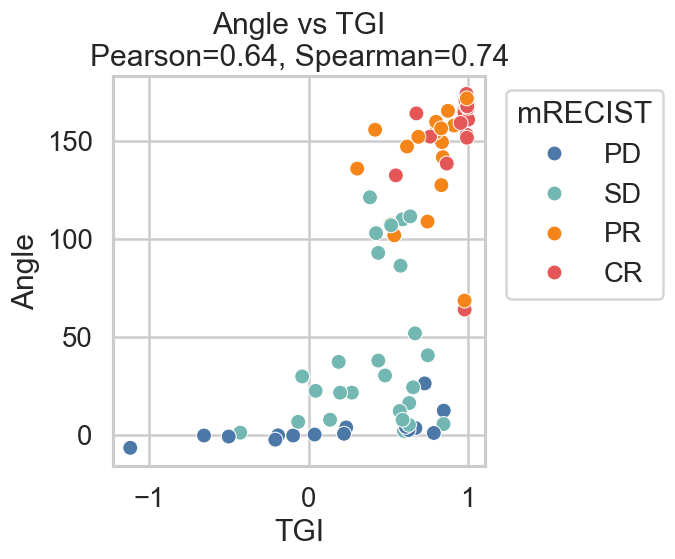

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(
    data=metadata_df,
    x="TGI",
    y="angle",
    hue="mRECIST",
    hue_order=MRECIST_ORDER,
    palette=PALETTE_MRECIST,
    s=80,
    edgecolor="white",
    linewidth=0.6,
    ax=ax,
)
pear = pearsonr(metadata_df["TGI"], metadata_df["angle"]).statistic
spear = spearmanr(metadata_df["TGI"], metadata_df["angle"]).statistic
ax.set_title(f"Angle vs TGI\nPearson={pear:.2f}, Spearman={spear:.2f}")
ax.set_xlabel("TGI")
ax.set_ylabel("Angle")
ax.legend(title="mRECIST", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
savefig("angle_vs_tgi_scatter")
plt.show()


## Figure 2: Single-omics and Multi-omics Benchmark

In [6]:
plot_models = [
    ("single_omics", "rna_paired", "logistic_l2", "RNA only\nLogistic L2"),
    ("single_omics", "cnv", "random_forest", "CNV only\nRandom forest"),
    ("single_omics", "mutation", "svm_rbf", "Mutation only\nSVM RBF"),
    ("early_fusion", "rna_cnv_mutation", "random_forest", "Early fusion\nRandom forest"),
    ("late_fusion_stacking", "rna_cnv_mutation", "stack_logistic_l2", "Late fusion\nStack logistic L2"),
]

rows = []
for analysis, omics, model, label in plot_models:
    sub = all_results_df[
        (all_results_df["analysis"] == analysis)
        & (all_results_df["omics"] == omics)
        & (all_results_df["model"] == model)
    ].copy()
    if sub.empty:
        print("Missing:", analysis, omics, model)
        continue
    sub["plot_label"] = label
    rows.append(sub)

benchmark_df = pd.concat(rows, ignore_index=True)
benchmark_df["plot_label"] = pd.Categorical(
    benchmark_df["plot_label"],
    categories=[x[3] for x in plot_models],
    ordered=True,
)

benchmark_summary_df = (
    benchmark_df
    .groupby("plot_label")[["auroc", "auprc", "balanced_accuracy", "f1"]]
    .agg(["mean", "std"])
    .round(3)
)
benchmark_summary_df


auroc         auprc        balanced_accuracy  \
                                 mean    std   mean    std              mean   
plot_label                                                                     
RNA only\nLogistic L2           0.643  0.124  0.688  0.116             0.613   
CNV only\nRandom forest         0.534  0.150  0.590  0.133             0.527   
Mutation only\nSVM RBF          0.500  0.149  0.565  0.124             0.487   
Early fusion\nRandom forest     0.658  0.134  0.667  0.112             0.613   
Late fusion\nStack logistic L2  0.544  0.160  0.606  0.142             0.538   

                                          f1         
                                  std   mean    std  
plot_label                                           
RNA only\nLogistic L2           0.094  0.611  0.091  
CNV only\nRandom forest         0.125  0.514  0.139  
Mutation only\nSVM RBF          0.039  0.321  0.300  
Early fusion\nRandom forest     0.121  0.555  0.149  
Late fusion\nStack logistic L2  0.118  0.519  0.135

saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/model_benchmark_auroc.png
saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/model_benchmark_auroc.pdf


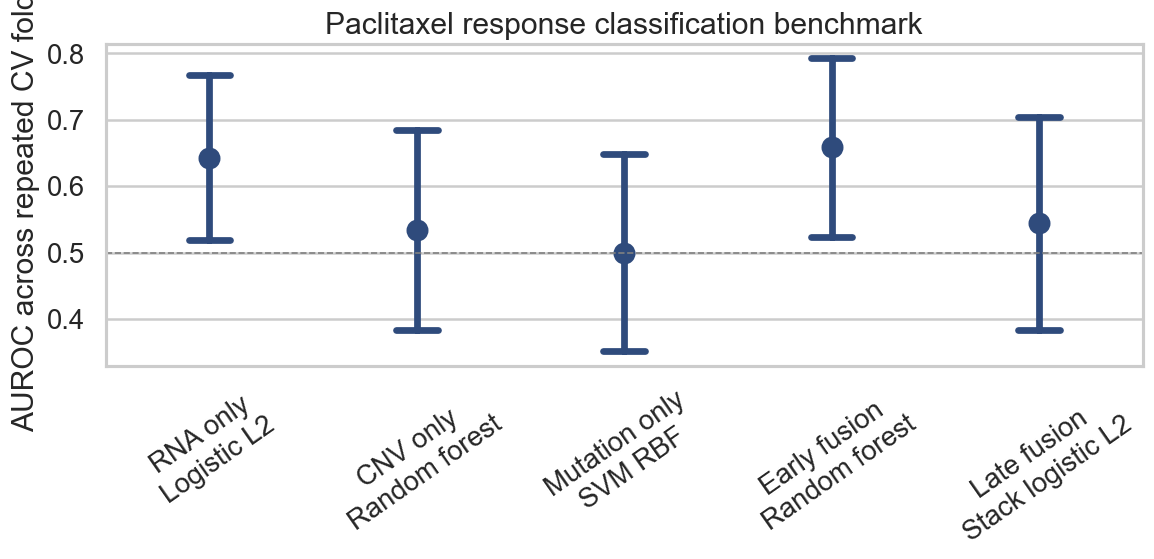

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.pointplot(
    data=benchmark_df,
    x="plot_label",
    y="auroc",
    errorbar="sd",
    join=False,
    capsize=0.2,
    color="#2F4B7C",
    ax=ax,
)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_title("Paclitaxel response classification benchmark")
ax.set_xlabel("")
ax.set_ylabel("AUROC across repeated CV folds")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
savefig("model_benchmark_auroc")
plt.show()

saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/model_benchmark_multi_metric.png
saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/model_benchmark_multi_metric.pdf


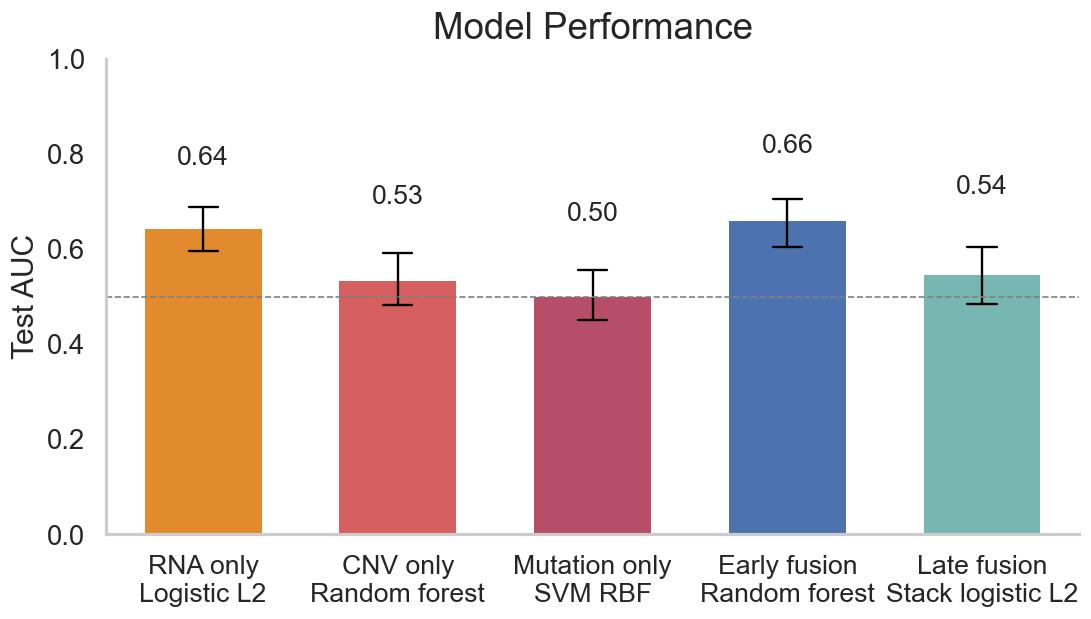

In [8]:
auroc_palette = {
    "RNA only\nLogistic L2": "#E28A2E",          # single omics: blue
    "CNV only\nRandom forest": "#D65F5F",      # single omics: teal
    "Mutation only\nSVM RBF": "#B64E68",       # single omics: orange
    "Early fusion\nRandom forest": "#4C72B0",  # fusion: red
    "Late fusion\nStack logistic L2": "#76B7B2",  # fusion: deeper red
}

fig, ax = plt.subplots(figsize=(9.5, 5.5))
sns.barplot(
    data=benchmark_df,
    x="plot_label",
    y="auroc",
    palette=auroc_palette,
    errorbar=("ci", 95),
    saturation=1,
    capsize=0.15,
    err_kws={"color": "black", "linewidth": 1.4},
    ax=ax,
    width=0.6
)

for patch in ax.patches:
    patch.set_edgecolor("none")
    patch.set_linewidth(0)

bar_summary = (
    benchmark_df
    .groupby("plot_label", observed=False)["auroc"]
    .agg(["mean", "std"])
    .reindex(benchmark_df["plot_label"].cat.categories)
)
for xpos, (_, row) in enumerate(bar_summary.iterrows()):
    label_y = min(row["mean"] + row["std"], 0.97)
    ax.text(
        xpos,
        label_y,
        f"{row['mean']:.2f}",
        ha="center",
        va="bottom",
        fontsize=16
    )

ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_title("Model Performance", pad=12, fontsize=22)
ax.set_xlabel("")
ax.set_ylabel("Test AUC")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0, labelsize=16)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
plt.tight_layout()
savefig("model_benchmark_multi_metric")
plt.show()


## Figure 3: ROC and Precision-Recall Curves for Representative Models

Curves pool held-out predictions across repeated CV folds. Because each sample appears in multiple held-out folds across repeats, these curves are descriptive summaries of cross-validated predictions.

saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/roc_curves_representative_models.png
saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/roc_curves_representative_models.pdf


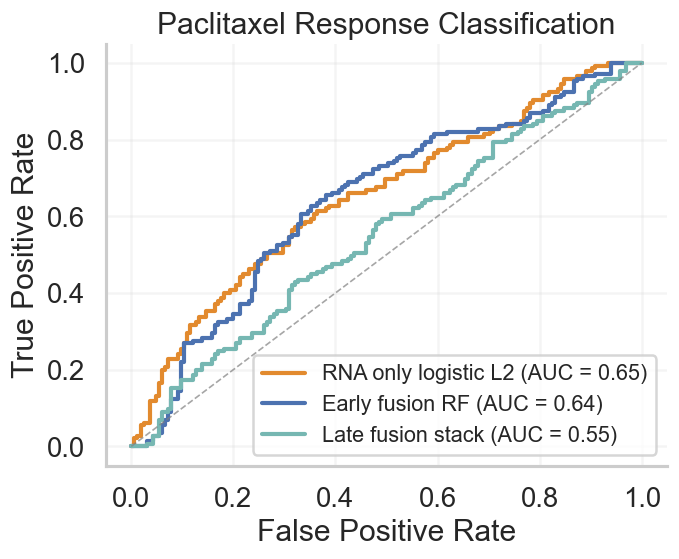

In [9]:
curve_models = [
    ("single_omics", "rna_paired", "logistic_l2", "RNA only logistic L2", "#E28A2E"),
    ("early_fusion", "rna_cnv_mutation", "random_forest", "Early fusion RF", "#4C72B0"),
    ("late_fusion_stacking", "rna_cnv_mutation", "stack_logistic_l2", "Late fusion stack", "#76B7B2"),
]

fig, ax = plt.subplots(figsize=(6, 5))

for analysis, omics, model, label, color in curve_models:
    try:
        sub = pooled_curve_data(all_predictions_df, model=model, analysis=analysis, omics=omics)
    except ValueError as err:
        print(err)
        continue

    fpr, tpr, _ = roc_curve(sub["y_true"], sub["y_score_sensitive"])
    roc_val = roc_auc_score(sub["y_true"], sub["y_score_sensitive"])
    ax.plot(fpr, tpr, linewidth=2.5, label=f"{label} (AUC = {roc_val:.2f})", color=color)

ax.plot([0, 1], [0, 1], color="gray", linewidth=1, linestyle="--", alpha=0.7)
ax.set_title("Paclitaxel Response Classification", fontsize=18)
ax.set_xlabel("False Positive Rate", fontsize=18)
ax.set_ylabel("True Positive Rate", fontsize=18)
ax.legend(loc="lower right", fontsize=13)
ax.grid(alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
savefig("roc_curves_representative_models")
plt.show()

## Figure 4: Prediction Score Distributions

saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/early_fusion_rf_prediction_scores.png
saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/early_fusion_rf_prediction_scores.pdf


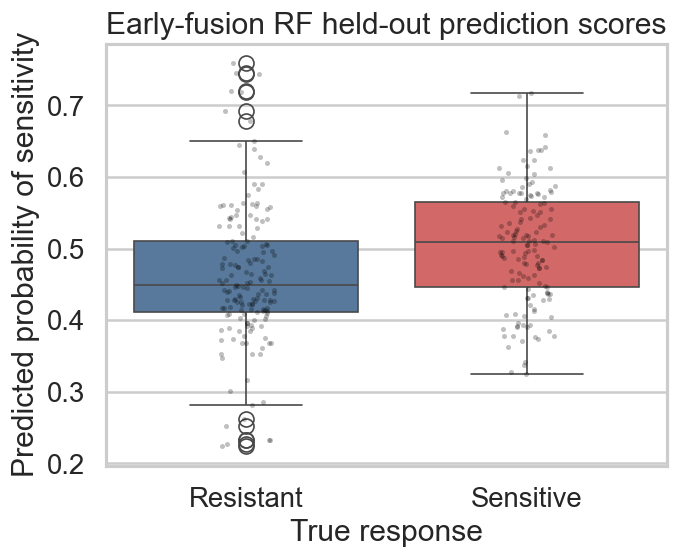

Mann-Whitney p: 1.2216607684614085e-05


In [10]:
best_pred_df = pooled_curve_data(
    all_predictions_df,
    model="random_forest",
    analysis="early_fusion",
    omics="rna_cnv_mutation",
).copy()
best_pred_df["true_response"] = best_pred_df["y_true_label"]

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(
    data=best_pred_df,
    x="true_response",
    y="y_score_sensitive",
    order=RESPONSE_ORDER,
    palette=PALETTE_BINARY,
    ax=ax,
)
sns.stripplot(
    data=best_pred_df,
    x="true_response",
    y="y_score_sensitive",
    order=RESPONSE_ORDER,
    color="black",
    alpha=0.25,
    size=3,
    ax=ax,
)
ax.set_title("Early-fusion RF held-out prediction scores")
ax.set_xlabel("True response")
ax.set_ylabel("Predicted probability of sensitivity")
plt.tight_layout()
savefig("early_fusion_rf_prediction_scores")
plt.show()

resistant = best_pred_df.loc[best_pred_df["true_response"] == "Resistant", "y_score_sensitive"]
sensitive = best_pred_df.loc[best_pred_df["true_response"] == "Sensitive", "y_score_sensitive"]
print("Mann-Whitney p:", mannwhitneyu(resistant, sensitive, alternative="two-sided").pvalue)

## Export Manuscript Summary Tables

In [11]:
benchmark_summary_flat_df = (
    benchmark_df
    .groupby(["plot_label", "analysis", "omics", "model"])
    .agg(
        auroc_mean=("auroc", "mean"),
        auroc_sd=("auroc", "std"),
        auprc_mean=("auprc", "mean"),
        auprc_sd=("auprc", "std"),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_sd=("balanced_accuracy", "std"),
        f1_mean=("f1", "mean"),
        sensitivity_mean=("sensitivity", "mean"),
        specificity_mean=("specificity", "mean"),
        n_features_mean=("n_features", "mean"),
    )
    .reset_index()
)
benchmark_summary_flat_df.to_csv(RESULTS_DIR / "manuscript_benchmark_summary.csv", index=False)
benchmark_summary_flat_df.round(3)

,plot_label,analysis,omics,model,auroc_mean,auroc_sd,auprc_mean,auprc_sd,balanced_accuracy_mean,balanced_accuracy_sd,f1_mean,sensitivity_mean,specificity_mean,n_features_mean
0,RNA only\nLogistic L2,early_fusion,cnv,logistic_l2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RNA only\nLogistic L2,early_fusion,cnv,random_forest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RNA only\nLogistic L2,early_fusion,cnv,stack_logistic_l2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RNA only\nLogistic L2,early_fusion,cnv,svm_rbf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,RNA only\nLogistic L2,early_fusion,mutation,logistic_l2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,Late fusion\nStack logistic L2,single_omics,rna_cnv_mutation,svm_rbf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
236,Late fusion\nStack logistic L2,single_omics,rna_paired,logistic_l2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
237,Late fusion\nStack logistic L2,single_omics,rna_paired,random_forest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
238,Late fusion\nStack logistic L2,single_omics,rna_paired,stack_logistic_l2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
